In [1]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0 = all logs, 1 = INFO, 2 = WARNING, 3 = ERROR only
import warnings
warnings.filterwarnings("ignore")

In [2]:
import tensorflow as tf

In [3]:
import sys
# Force early GPU initialization
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        with tf.device('/GPU:0'):
            _ = tf.constant([1.0])
    except RuntimeError as e:
        print(f"RuntimeError during GPU warm-up: {e}")

print("\n" + "="*60)
print("TENSORFLOW GPU TEST RESULTS")
print("="*60)

# TensorFlow version
print(f"TensorFlow Version: {tf.__version__}")

# Python version
print(f"Python Version: {sys.version.split()[0]}")

# CUDA and cuDNN support (inferred)
build_info = tf.sysconfig.get_build_info()
cuda_version = build_info.get('cuda_version', 'Unknown')
cudnn_version = build_info.get('cudnn_version', 'Unknown')

print(f"CUDA Version (from build): {cuda_version}")
print(f"cuDNN Version (from build): {cudnn_version}")

# GPU status
gpu_available = len(gpus) > 0
print(f"\nGPU Available: {gpu_available}")

if gpu_available:
    for idx, gpu in enumerate(gpus):
        print(f"GPU {idx}: {gpu.name}")
else:
    print("No GPU devices detected. Defaulting to CPU.")

# Matrix multiplication test
print(f"\nRunning matrix multiplication test...")
with tf.device('/GPU:0' if gpu_available else '/CPU:0'):
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 0.0], [0.0, 1.0]])
    c = tf.matmul(a, b)

print(f"Result:")
print(c.numpy())
print("\nTest completed successfully.")
print("="*60)


TENSORFLOW GPU TEST RESULTS
TensorFlow Version: 2.15.0
Python Version: 3.10.12
CUDA Version (from build): 12.2
cuDNN Version (from build): 8

GPU Available: True
GPU 0: /physical_device:GPU:0

Running matrix multiplication test...
Result:
[[1. 2.]
 [3. 4.]]

Test completed successfully.


In [4]:
import requests
import pandas as pd
import tensorflow as tf
import os
import random
import numpy as np

In [5]:
# Define the URL and target path
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
save_path = "/home/jwens/PycharmProjects/School-Projects/Graduate Projects - MS AI and Machine Learning/CSC580 Capstone/data/Iris/iris.data"

# Ensure the directory exists
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Download and save the file
r = requests.get(url)
with open(save_path, 'wb') as f:
    f.write(r.content)

In [6]:
# Load Iris dataset with defined column names
iris_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
iris_df = pd.read_csv(save_path, header=None, names=iris_columns)


In [7]:
# Encode class labels as integers
label_map = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}
iris_df["class"] = iris_df["class"].map(label_map)
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [8]:
# Shuffle the dataset
iris_df = iris_df.sample(frac=1.0, random_state=4321)

# Separate features and labels
x = iris_df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = iris_df["class"]

# Center features by subtracting the mean
x = x - x.mean(axis=0)

# One-hot encode labels
y = tf.one_hot(y, depth=3)
y = tf.cast(y, tf.float32)
print(x)

     sepal_length  sepal_width  petal_length  petal_width
31      -0.443333        0.346     -2.258667    -0.798667
23      -0.743333        0.246     -2.058667    -0.698667
70       0.056667        0.146      1.041333     0.601333
100      0.456667        0.246      2.241333     1.301333
44      -0.743333        0.746     -1.858667    -0.798667
..            ...          ...           ...          ...
113     -0.143333       -0.554      1.241333     0.801333
91       0.256667       -0.054      0.841333     0.201333
146      0.456667       -0.554      1.241333     0.701333
124      0.856667        0.246      1.941333     0.901333
61       0.056667       -0.054      0.441333     0.301333

[150 rows x 4 columns]


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import backend as K

K.clear_session()
# Define the neural network model
model = Sequential([
    Dense(32, activation='relu', input_shape=(4,)),  # Input layer (4 features) + 32-node hidden layer
    Dense(16, activation='relu'),                    # Second hidden layer
    Dense(3, activation='softmax')                   # Output layer for 3 classes
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                160       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 3)                 51        
                                                                 
Total params: 739 (2.89 KB)
Trainable params: 739 (2.89 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
history = model.fit(
    x,                # Centered feature matrix
    y,                # One-hot encoded labels
    batch_size=64,
    epochs=25,
    verbose=1         # Shows progress bar per epoch
)

Epoch 1/25


I0000 00:00:1753641943.699837  180986 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 [==============================] - 1s 4ms/step - loss: 1.0669 - accuracy: 0.6267
Epoch 2/25
3/3 [==============================] - 0s 2ms/step - loss: 1.0222 - accuracy: 0.6667
Epoch 3/25
3/3 [==============================] - 0s 2ms/step - loss: 0.9800 - accuracy: 0.6667
Epoch 4/25
3/3 [==============================] - 0s 2ms/step - loss: 0.9418 - accuracy: 0.6600
Epoch 5/25
3/3 [==============================] - 0s 2ms/step - loss: 0.9083 - accuracy: 0.6400
Epoch 6/25
3/3 [==============================] - 0s 2ms/step - loss: 0.8772 - accuracy: 0.6333
Epoch 7/25
3/3 [==============================] - 0s 2ms/step - loss: 0.8495 - accuracy: 0.6333
Epoch 8/25
3/3 [==============================] - 0s 2ms/step - loss: 0.8222 - accuracy: 0.6133
Epoch 9/25
3/3 [==============================] - 0s 2ms/step - loss: 0.7972 - accuracy: 0.6400
Epoch 10/25
3/3 [==============================] - 0s 2ms/step - loss: 0.7773 - accuracy: 0.6600
Epoch 11/25
3/3 [==============================] -

In [11]:
def fix_random_seed(seed):
    try:
        np.random.seed(seed)
    except NameError:
        print("Warning: Numpy is not imported. Setting the seed for Numpy failed.")
    try:
        tf.random.set_seed(seed)
    except NameError:
        print("Warning: TensorFlow is not imported. Setting the seed for TensorFlow failed.")
    try:
        random.seed(seed)
    except NameError:
        print("Warning: random module is not imported. Setting the seed for random failed.")

# Fixing the random seed
fix_random_seed(4321)


In [12]:
#Functional API
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model

In [13]:
inp1 = Input(shape=(4,))  # raw iris features (e.g., petal and sepal)
inp2 = Input(shape=(2,))  # PCA features (2 principal components)
out1 = Dense(16, activation='relu')(inp1)
out2 = Dense(16, activation='relu')(inp2)

In [14]:
concat = Concatenate(axis=1)
out = concat([out1, out2])
out = Dense(16, activation='relu')(out)
out = Dense(3, activation='softmax')(out)
model = Model(inputs=[inp1, inp2], outputs=out)
model.compile(loss='categorical_crossentropy', optimizer='adam',
metrics=['acc'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 4)]                  0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 2)]                  0         []                            
                                                                                                  
 dense_3 (Dense)             (None, 16)                   80        ['input_1[0][0]']             
                                                                                                  
 dense_4 (Dense)             (None, 16)                   48        ['input_2[0][0]']             
                                                                                              

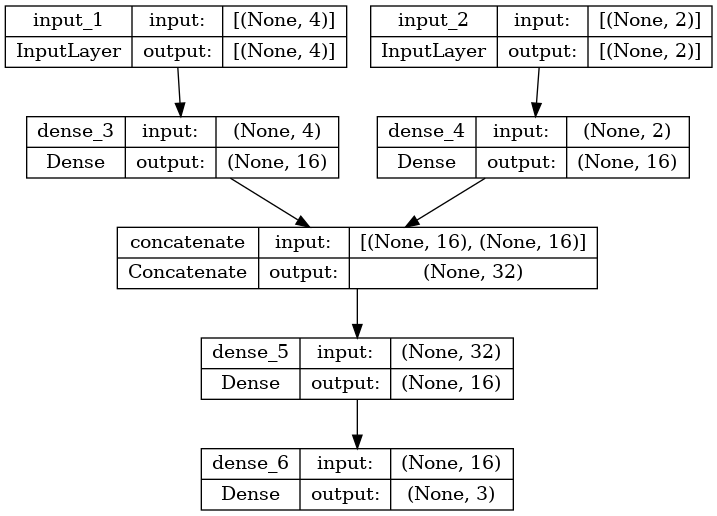

In [15]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)